<a href="https://colab.research.google.com/github/sanjaikmca/Academic-Project-Image-Captioning/blob/main/Image_caption_generator_(26_04).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Modules

In [ ]:
import os   # handling the files
import pickle # storing numpy features
import numpy as np
from tqdm.notebook import tqdm # how much data is process till now

from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input # extract features from image data.
from tensorflow.keras.preprocessing.image import load_img , img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input , Dense , LSTM , Embedding , Dropout , add

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pickle
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model

# Define directories correctly
WORKING_DIR = '/content/drive/MyDrive/Working'    # Where to save features.pkl
BASE_DIR = '/content/drive/MyDrive'               # Base folder path
IMAGE_DIR = os.path.join(BASE_DIR, 'Images')       # Images folder
CAPTIONS_FILE = os.path.join(BASE_DIR, 'captions.txt')  # Captions file

# Load the pre-trained VGG16 model (up to the second last layer)
vgg_model = VGG16()
model = Model(inputs=vgg_model.inputs, outputs=vgg_model.layers[-2].output)

# Extract features from images
features = {}

print("Extracting image features...")

for img_name in tqdm(os.listdir(IMAGE_DIR)):
    img_path = os.path.join(IMAGE_DIR, img_name)
    try:
        # Load and preprocess image
        image = load_img(img_path, target_size=(224, 224))
        image = img_to_array(image)
        image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
        image = preprocess_input(image)

        # Extract features
        feature = model.predict(image, verbose=0)

        # Get image ID (without extension)
        image_id = img_name.split('.')[0]

        # Store features
        features[image_id] = feature
    except Exception as e:
        print(f"Skipping {img_name}: {e}")

# Save features to pickle file
os.makedirs(WORKING_DIR, exist_ok=True)
features_path = os.path.join(WORKING_DIR, 'features.pkl')
with open(features_path, 'wb') as f:
    pickle.dump(features, f)

print(f"Features saved to {features_path}")

# Load features from pickle (optional step to verify)
with open(features_path, 'rb') as f:
    features = pickle.load(f)

print(f"Loaded features: {len(features)} images")

# Load captions file
print("Processing captions file...")
with open(CAPTIONS_FILE, 'r') as f:
    next(f)  # Skip header if needed
    captions_doc = f.read()

# Create mapping of image IDs to captions
mapping = {}

# Process each line in captions file
for line in tqdm(captions_doc.strip().split('\n')):
    tokens = line.split(',')
    if len(tokens) < 2:
        continue
    image_id, caption_tokens = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption_tokens).strip()
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

print('Total images with captions:', len(mapping))


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Extracting image features...


100%|██████████| 181/181 [02:35<00:00,  1.16it/s]

Skipping captions.txt: cannot identify image file <_io.BytesIO object at 0x7cb484117ce0>
Features saved to /content/drive/MyDrive/Working/features.pkl
Loaded features: 180 images
Processing captions file...



100%|██████████| 40455/40455 [00:00<00:00, 594783.98it/s]

Total images with captions: 8091


# Preprocess Text Data

In [ ]:
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # take one caption at a time
            caption = captions[i]
            # preprocessing steps
            # convert to lowercase
            caption = caption.lower()
            # delete digits, special chars, etc.,
            caption = caption.replace('[^A-Za-z]', '')
            # delete additional spaces
            caption = caption.replace('\s+', ' ')
            # add start and end tags to the caption
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            captions[i] = caption

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1956/3802969776.py:12: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')


Defined to clean and convert the text for quicker process and better results

Let us visualize the text **before** and **after** cleaning

In [ ]:
# before preprocess of text
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [ ]:
# preprocess the text
clean(mapping)

In [ ]:
# after preprocess of text
mapping['1000268201_693b08cb0e']

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

#### Next we will store the preprocessed captions into a list

In [ ]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [ ]:
len(all_captions)

40455

No. of unique captions stored

# 10 Captions
Let us see the first ten captions

In [ ]:
all_captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri-colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

# Processing of Text Data
Now we start processing the text data

In [ ]:
# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

In [ ]:
vocab_size

8485

No. of unique words

In [ ]:
# get maximum length of the caption available
max_length = max(len(caption.split()) for caption in all_captions)
max_length

35

+ Finding the maximum length of the captions, used for reference for the padding sequence.

# Train Test Split

#### After preprocessing the data now we will train, test and split

In [ ]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

**Now we will define a batch and include the padding sequence**

In [ ]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq],num_classes=vocab_size)[0]
                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield [X1, X2], y
                X1, X2, y = list(), list(), list()
                n = 0

Padding sequence normalizes the size of all captions to the max size filling them with zeros for better results.

# Model Creation

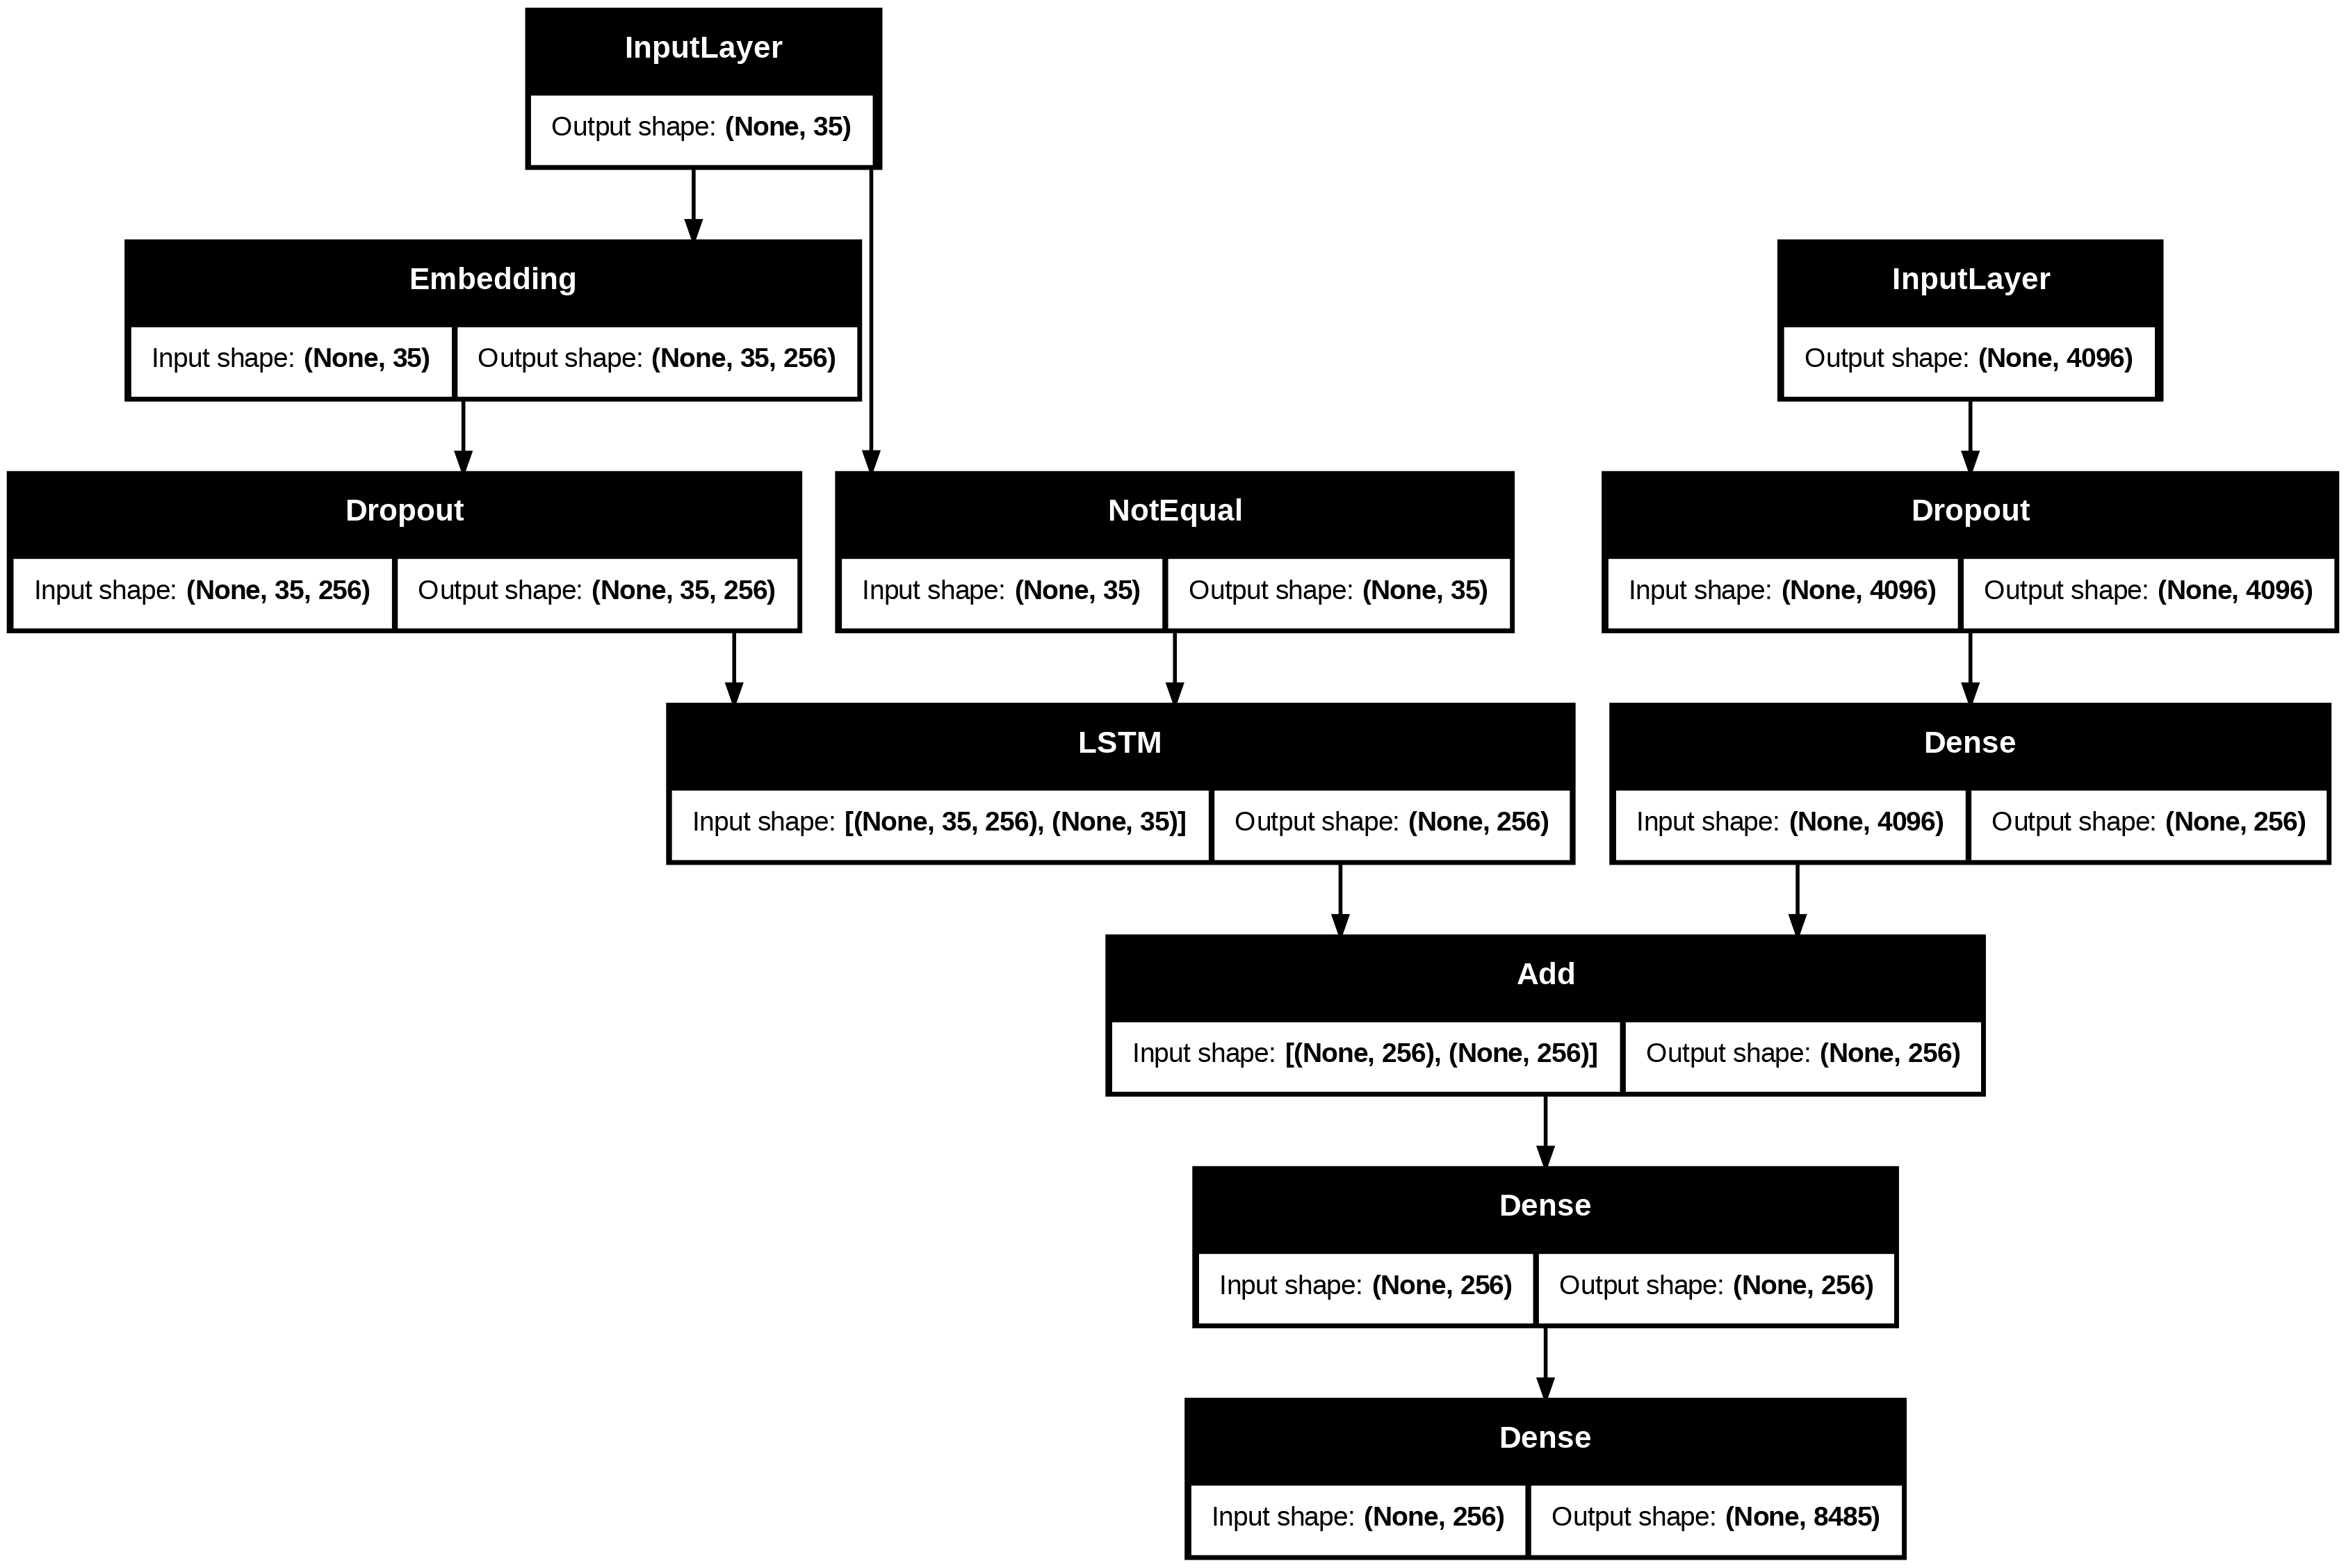

In [ ]:
# encoder model
# image feature layers
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)

+ **shape=(4096,)** - output length of the features from the VGG model

+ **Dense** - single dimension linear layer array

+ **Dropout()** - used to add regularization to the data, avoiding over fitting & dropping out a fraction of the data from the layers

+ **model.compile()** - compilation of the model

+ **loss=’sparse_categorical_crossentropy’** - loss function for category outputs

+ **optimizer=’adam’** - automatically adjust the learning rate for the model over the no. of epochs

+ Model plot shows the concatenation of the inputs and outputs into a single layer

+ Feature extraction of image was already done using VGG, no CNN model was needed in this step.

# Train Model
Now let us train the model

In [ ]:
import tensorflow as tf

def tf_data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size):
    def gen():
        for key in data_keys:
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    yield (features[key][0], in_seq), out_seq

    output_signature = (
        (tf.TensorSpec(shape=(4096,), dtype=tf.float32), tf.TensorSpec(shape=(max_length,), dtype=tf.int32)),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
    )
    return tf.data.Dataset.from_generator(gen, output_signature=output_signature)

# --- training loop ---

epochs = 1
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # create TensorFlow dataset
    dataset = tf_data_generator(train, mapping, features, tokenizer, max_length, vocab_size)
    dataset = dataset.batch(batch_size)

    # fit for one epoch
    model.fit(dataset, epochs=1, steps_per_epoch=steps, verbose=1)


227/227 ━━━━━━━━━━━━━━━━━━━━ 70s 289ms/step - loss: 6.2786


In [ ]:
# save the model
model.save(WORKING_DIR+'/best_model.h5')

# Generate Captions for the Image

In [ ]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

+ Convert the predicted index from the model into a word

In [ ]:
# generate caption for an image
def predict_caption(model, image, tokenizer, max_length):
    # add start tag for generation process
    in_text = 'startseq'
    # iterate over the max length of sequence
    for i in range(max_length):
        # encode input sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # pad the sequence
        sequence = pad_sequences([sequence], max_length)
        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        # get index with high probability
        yhat = np.argmax(yhat)
        # convert index to word
        word = idx_to_word(yhat, tokenizer)
        # stop if word not found
        if word is None:
            break
        # append word as input for generating next word
        in_text += " " + word
        # stop if we reach end tag
        if word == 'endseq':
            break
    return in_text

+ Captiongenerator appending all the words for an image

+ The caption starts with 'startseq' and the model continues to predict the caption until the 'endseq' appeared

# Model Validation
Now we validate the data using BLEU Score

In [ ]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = list(), list()

for key in tqdm(test):
    if key not in features:
        continue  # skip if no feature available

    captions = mapping[key]
    y_pred = predict_caption(model, features[key], tokenizer, max_length)

    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()

    actual.append(actual_captions)
    predicted.append(y_pred)



100%|██████████| 810/810 [00:00<00:00, 1382737.58it/s]


+ BLEU Score is used to evaluate the predicted text against a reference text, in a list of tokens.

+ The reference text contains all the words appended from the captions data (actual_captions)

+ A BLEU Score more than **0.4 is considered a good result**, for a better score increase the no. of epochs accordingly.

## Visualize the Results

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    # load the image
    # image_name = "1001773457_577c3a7d70.jpg"
    image_id = image_name.split('.')[0]
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

+ Image caption generator defined

+ First prints the actual captions of the image then prints a predicted caption of the image

---------------------Actual---------------------
startseq corgi runs out of tunnel endseq
startseq dog runs out of tunnel on course endseq
startseq dog running out of tunnel on obstacle course endseq
startseq the dog is running out of the tunnel on dog obedience course endseq
startseq the small brown and white dog is running out of small tunnel endseq
--------------------Predicted--------------------
startseq brown brown brown the endseq


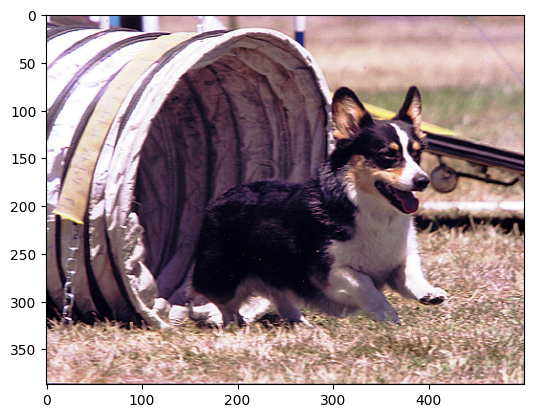

In [ ]:
generate_caption("1095580424_76f0aa8a3e.jpg")

---------------------Actual---------------------
startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq
startseq little girl is sitting in front of large painted rainbow endseq
startseq small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it endseq
startseq there is girl with pigtails sitting in front of rainbow painting endseq
startseq young girl with pigtails painting outside in the grass endseq
--------------------Predicted--------------------
startseq in in in endseq


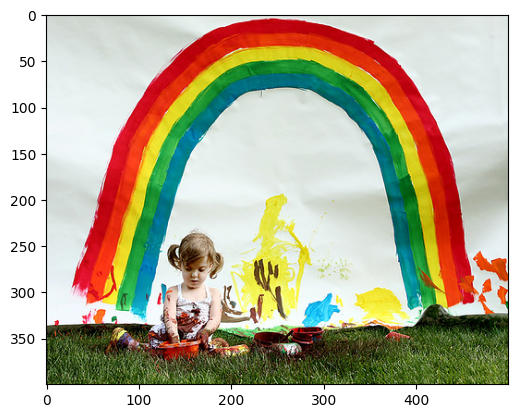

In [ ]:
generate_caption("1002674143_1b742ab4b8.jpg")

---------------------Actual---------------------
startseq man in hat is displaying pictures next to skier in blue hat endseq
startseq man skis past another man displaying paintings in the snow endseq
startseq person wearing skis looking at framed pictures set up in the snow endseq
startseq skier looks at framed pictures in the snow next to trees endseq
startseq man on skis looking at artwork for sale in the snow endseq
--------------------Predicted--------------------
startseq two the the endseq


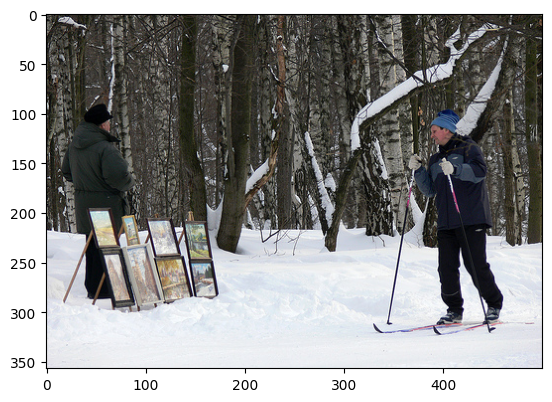

In [ ]:
generate_caption("101669240_b2d3e7f17b.jpg")

---------------------Actual---------------------
startseq blonde horse and blonde girl in black sweatshirt are staring at fire in barrel endseq
startseq girl and her horse stand by fire endseq
startseq girl holding horse 's lead behind fire endseq
startseq "a man and girl and two horses are near contained fire ." endseq
startseq two people and two horses watching fire endseq
--------------------Predicted--------------------
startseq two in in endseq


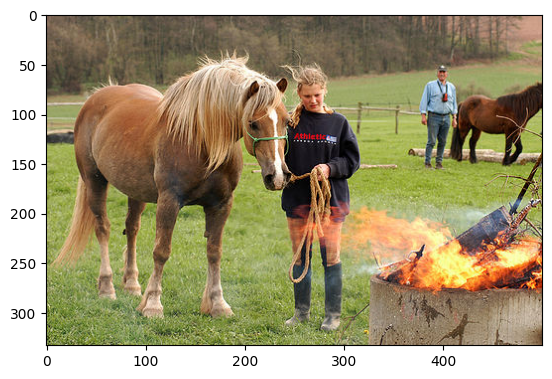

In [ ]:
generate_caption("10815824_2997e03d76.jpg")

# Final Thoughts

+ Training the model by increasing the no. of epochs can give better and more accurate results.

+ Processing large amount of data can take a lot of time and system resource.

+ The no. of layers of the model can be increased if you want to process large dataset like flickr32k.



**In this project , we have built an Image Caption Generator exploring the Flickr Dataset as an advanced deep learning project using different models from image extraction and text based processing.**

---------------------Actual---------------------
startseq crowd watching air balloons at night endseq
startseq group of hot air balloons lit up at night endseq
startseq people are watching hot air balloons in the park endseq
startseq people watching hot air balloons endseq
startseq seven large balloons are lined up at nighttime near crowd endseq
--------------------Predicted--------------------
startseq brown brown brown on on on endseq


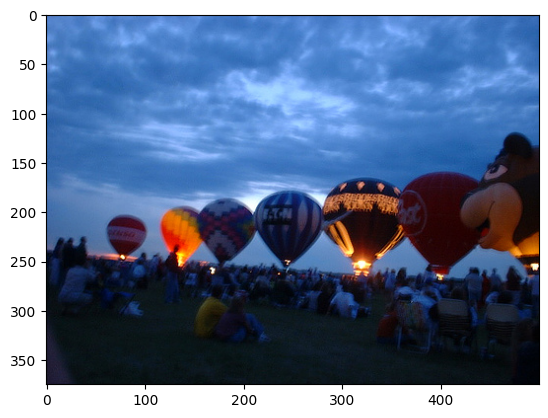

In [ ]:
generate_caption("107318069_e9f2ef32de.jpg")

---------------------Actual---------------------
startseq snowboarder sits on slope with skiers and boarders nearby endseq
startseq snowboarder takes rest on the mountainside endseq
startseq snowboarders sitting in the snow while skiers take the hill endseq
startseq the snowboarder is sitting down endseq
startseq "two skiers stand two sit on slopes ." endseq
--------------------Predicted--------------------
startseq the the endseq


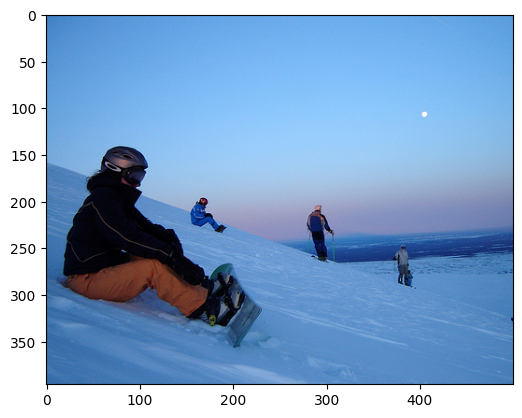

In [ ]:
generate_caption("113678030_87a6a6e42e.jpg")

In [ ]:
generate_caption("115684808_cb01227802.jp")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Images/115684808_cb01227802.jp'

In [ ]:
# Reload the captions file and recreate the mapping dictionary
CAPTIONS_FILE = os.path.join(BASE_DIR, 'dataset.txt')  # Captions file

mapping_before_clean = {}

print("Processing captions file again...")
with open(CAPTIONS_FILE, 'r') as f:
    next(f)  # Skip header if needed
    captions_doc = f.read()

# Process each line in captions file
for line in tqdm(captions_doc.strip().split('\n')):
    tokens = line.split(',')
    if len(tokens) < 2:
        continue
    image_id, caption_tokens = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption_tokens).strip()
    if image_id not in mapping_before_clean:
        mapping_before_clean[image_id] = []
    mapping_before_clean[image_id].append(caption)

print('Total images with captions (before clean):', len(mapping_before_clean))

# Now print a caption using a key that should exist
print("\nCaption before cleaning:")
print(mapping_before_clean['1000268201_693b08cb0e'])

Processing captions file again...


100%|██████████| 42684/42684 [00:00<00:00, 487801.99it/s]

Total images with captions (before clean): 4894

Caption before cleaning:


KeyError: '1000268201_693b08cb0e'